In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from xgboost import plot_importance
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import shap
from pathlib import Path
import sys
base_dir = Path().resolve().parent
sys.path.append(str(base_dir / "src"))
from helpers.tree_data import tree_data

data_dir = base_dir / "data"
dataset = "telco_customer_churn_clean.csv"

X_train, X_test, y_train, y_test = tree_data(data_dir / dataset)

Dataset 'C:\Users\HP\Desktop\Telco_Customer_Churn\data\telco_customer_churn_clean.csv' loaded successfully.

TotalCharges was typecasted to numerical.

Null values were removed.


Dataset size : 
7032 rows
21 columns


Successfully dropped the column: 'customerID'
Dataset split complete.

Successfully encoded all columns


Training and testing datasets are ready to be used.



In [2]:
xgb_model = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.003,
    max_depth = 7,
    min_child_weight = 5,
    subsample = 0.8,
    colsample_bytree = 0.7,
    scale_pos_weight = 3,
    random_state = 42,
    verbosity = 2
)

xgb_model.fit(X_train, y_train)

[01:59:16] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (5625, 26, 146250).


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [3]:
model_dir = base_dir / "model"

joblib.dump(
    xgb_model,
    model_dir / "xgb_churn_model.pkl"
)

['C:\\Users\\HP\\Desktop\\Telco_Customer_Churn\\model\\xgb_churn_model.pkl']

In [4]:
y_pred = xgb_model.predict(X_test)
y_probs = xgb_model.predict_proba(X_test)[:,1]

In [5]:
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

metrics = {
    "Recall":recall,
    "Precision":precision,
    "F1 score":f1,
    "Accuracy":accuracy,
    "ROC-AUC":roc_auc
}

for metric,score in metrics.items():
    print(f"Metric : {metric} | Score : {score}")

Metric : Recall | Score : 0.8315508021390374
Metric : Precision | Score : 0.47480916030534354
Metric : F1 score | Score : 0.6044703595724004
Metric : Accuracy | Score : 0.7107320540156361
Metric : ROC-AUC | Score : 0.8375739629654556


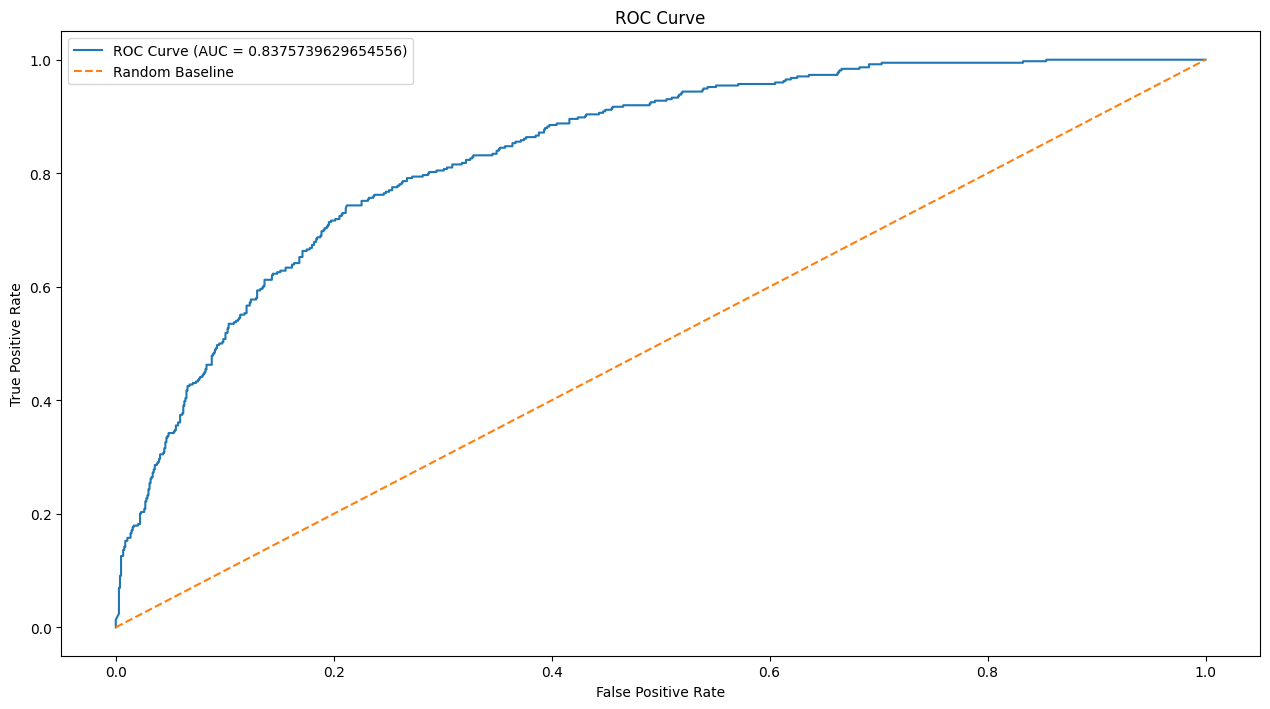

In [6]:
false_pos_rate, true_pos_rate, thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(12.8, 7.2))
plt.plot(
    false_pos_rate,
    true_pos_rate,
    label = f"ROC Curve (AUC = {roc_auc})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    label = "Random Baseline"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

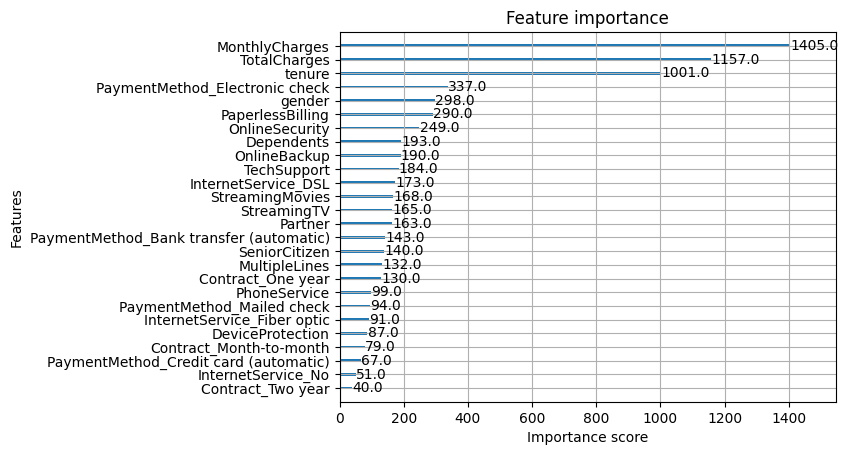

In [7]:
plot_importance(xgb_model)
plt.show()

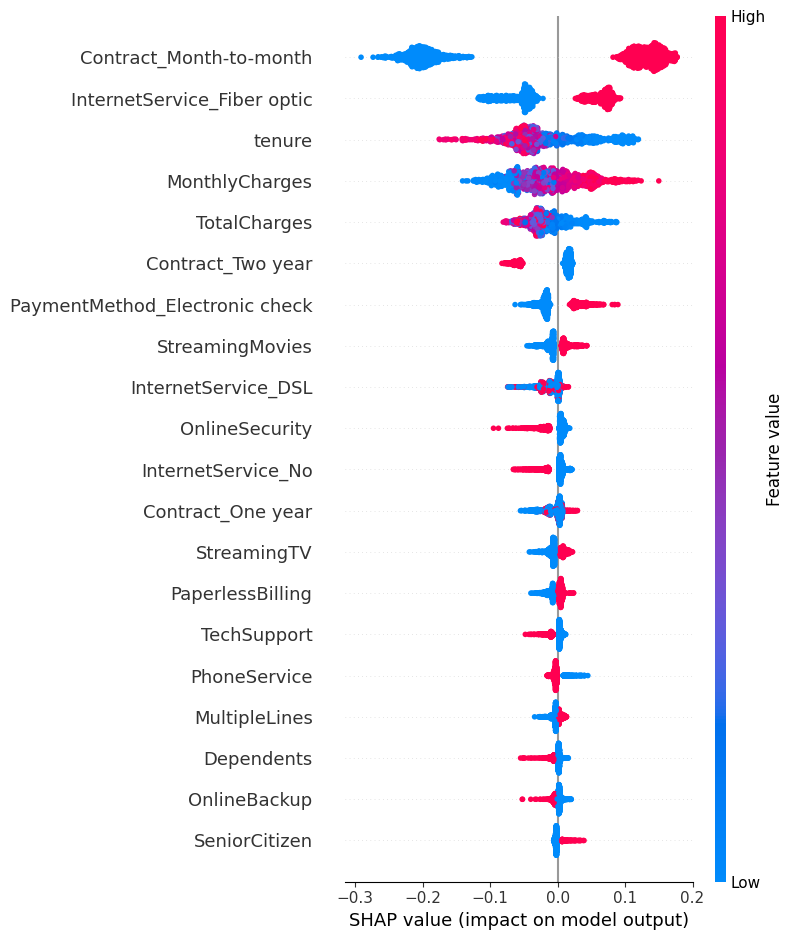

In [16]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.initjs()
shap.summary_plot(shap_values,X_test)